In [7]:
import numpy as np

import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI

from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
import pandas as pd
from matplotlib import pyplot as plt

from causal_graph_comparison.subsample import subsample_outputs

Detected non-Linux system, using scratch directory:  /Users/cisaicu/dev/mila/scratch


In [2]:
N_MODES = 4
TAU_MAX = 5
LAT = 40
LON = 40
N_SAMPLES = 995

In [3]:
# Step 1: Load the data
mlp_output = np.load("../outputs/test_results-2025_07_08_18_53_00.npz")

In [9]:
outputs = mlp_output["outputs"]
targets = mlp_output["target"]
inputs = mlp_output["inputs"]

print("MLP output shape: ", outputs.shape)
print("MLP target shape: ", targets.shape)
print("MLP inputs shape: ", inputs.shape)


MLP output shape:  (50, 1600)
MLP target shape:  (50, 1600)
MLP inputs shape:  (50, 5, 1600)


In [12]:
# Spatial subsampling of outputs for dimensionality reduction
subsampled_outputs = subsample_outputs(outputs, N_MODES)
subsampled_targets = subsample_outputs(targets, N_MODES)

Subsampled shape:  (50, 2, 2)
Subsampled shape:  (50, 2, 2)


Subsampled targets shape:  (50,)
Subsampled outputs shape:  (50,)


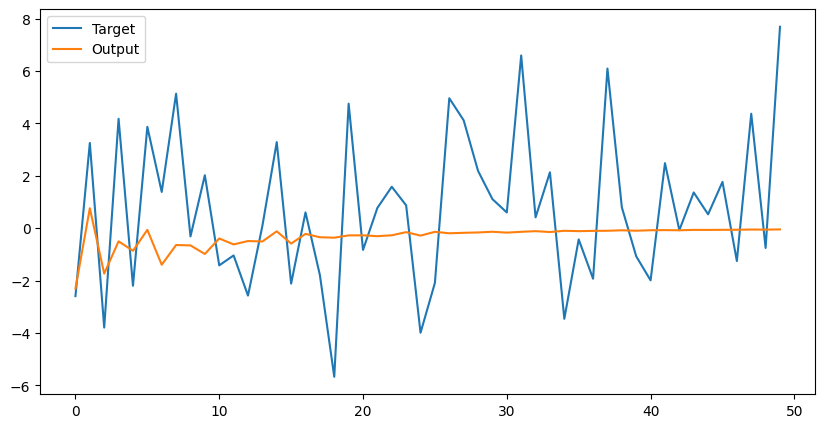

In [18]:
# Plot target and output of mlp in quadrant 1
test_targets = subsampled_targets[:, 0, 1]
test_outputs = subsampled_outputs[:, 0, 1]

print("Subsampled targets shape: ", test_targets.shape)
print("Subsampled outputs shape: ", test_outputs.shape)

# Plot target and output of mlp in quadrant 1
plt.figure(figsize=(10, 5))
plt.plot(test_targets, label="Target")
plt.plot(test_outputs, label="Output")
plt.legend()
plt.show()


In [24]:
# STEP 4: Learn causal graph using PCMCI+

# flatten the data
subsampled_outputs = subsampled_outputs.reshape(subsampled_outputs.shape[0], -1)
subsampled_targets = subsampled_targets.reshape(subsampled_targets.shape[0], -1)

# Create variable names for the modes
var_names = [f"mode_{i}" for i in range(N_MODES)]
dataframe = pp.DataFrame(subsampled_targets, var_names=var_names)

# Initialize PCMCI+
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr(),
    verbosity=2
)

# Run PCMCI+
results = pcmci.run_pcmci(
    tau_max=TAU_MAX,  # Maximum time lag
    pc_alpha=0.05  # Significance level
)

# Extract results
graph = results['graph']
val_matrix = results['val_matrix']
p_matrix = results['p_matrix']

print(f"\nPCMCI+ Results:")
print(f"Graph shape: {graph.shape}")
print(f"Value matrix shape: {val_matrix.shape}")
print(f"P-value matrix shape: {p_matrix.shape}")

# Print the discovered links
print(f"\nDiscovered causal links:")
for i in range(len(var_names)):
    for j in range(len(var_names)):
        for tau in range(TAU_MAX):
            if graph[i, j, tau] != "":
                print(f"{var_names[i]} <-{graph[i, j, tau]}- {var_names[j]} (lag {tau+1})")



##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 5
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Variable mode_0

Iterating through pc_alpha = [0.05]:

# pc_alpha = 0.05 (1/1):

Testing condition sets of dimension 0:

    Link (mode_0 -1) -?> mode_0 (1/20):
    Subset 0: () gives pval = 0.72008 / val =  0.058
    Non-significance detected.

    Link (mode_0 -2) -?> mode_0 (2/20):
    Subset 0: () gives pval = 0.03633 / val =  0.332
    No conditions of dimension 0 left.

    Link (mode_0 -3) -?> mode_0 (3/20):
    Subset 0: () gives pval = 0.41662 / val = -0.132
    Non-significance detected.

    Link (mode_0 -4) -?> mode_0 (4/20):
    Subset 0: () gives pval = 0.98151 / val =  0.004
    Non-significance detected.

    Link (mode_0 -5) -?> mode_0 (5/20):
    Subset 0: () gives pval = 0.32337 / val = -0.160
    Non-significance detected.

    Link (mode_1 -1) -?> mode_0 (6/20):
    Subset

In [25]:
# Step 5: Analyze mode relationships


print(f"\nStep 5: Analyzing mode relationships...")

# Calculate correlations between modes
correlations = np.corrcoef(subsampled_outputs.reshape(-1, 4).T)

print(f"\nCorrelation matrix between modes:")
print(pd.DataFrame(correlations, index=var_names, columns=var_names))

# Count causal links per mode
print(f"\nCausal link counts per mode:")
for i, mode in enumerate(var_names):
    incoming = np.sum(graph[i, :, :] != "")
    outgoing = np.sum(graph[:, i, :] != "")
    print(f"{mode}: {incoming} incoming, {outgoing} outgoing links")



Step 5: Analyzing mode relationships...

Correlation matrix between modes:
          mode_0    mode_1    mode_2    mode_3
mode_0  1.000000  0.758537  0.122592  0.389544
mode_1  0.758537  1.000000 -0.273322  0.565605
mode_2  0.122592 -0.273322  1.000000  0.080721
mode_3  0.389544  0.565605  0.080721  1.000000

Causal link counts per mode:
mode_0: 2 incoming, 1 outgoing links
mode_1: 0 incoming, 2 outgoing links
mode_2: 3 incoming, 1 outgoing links
mode_3: 0 incoming, 1 outgoing links



Step 6: Plotting causal graph...


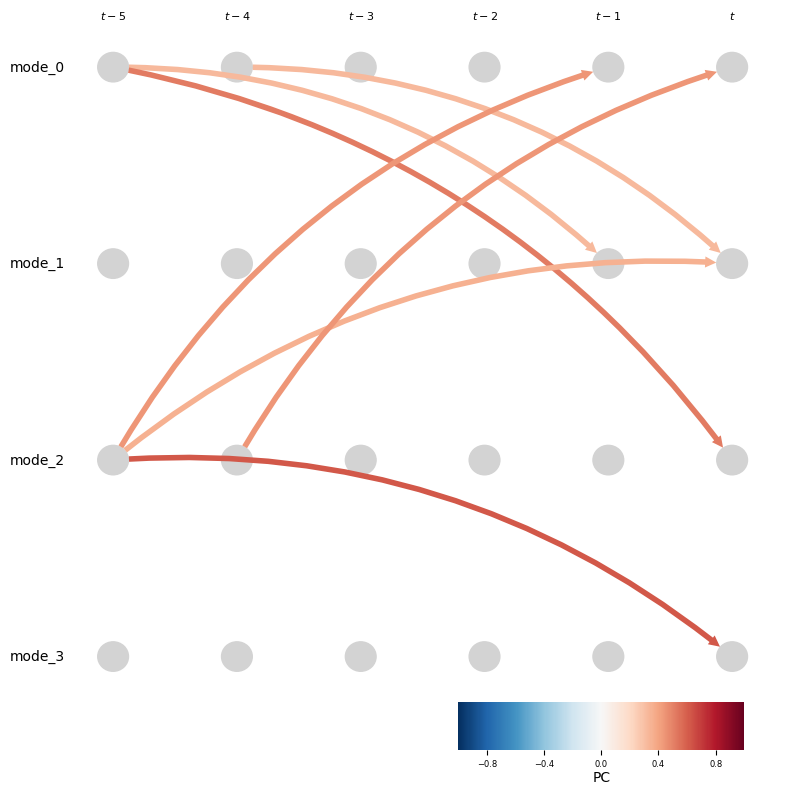

In [26]:
# Step 6: Plot causal graph
print(f"\nStep 6: Plotting causal graph...")

# Plot graph for each lag
tp.plot_time_series_graph(
    graph = graph,
    val_matrix=val_matrix,
    figsize=(8, 8),
    node_size=0.05,
    var_names=var_names,
    link_colorbar_label='PC')

plt.tight_layout()
# plt.savefig("causal_graph_example.png", dpi=300, bbox_inches='tight')
plt.show()